<a href="https://colab.research.google.com/github/Srivalarmathi/ClingeBridge-Solutions/blob/main/Data_Science_Trainee_Internship_Project_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Mall_Customers.csv to Mall_Customers.csv
Dataset Loaded Successfully

Dataset Shape: (200, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Summary Statistics:
        CustomerID   Genre         Age  Annual Income (k$)  \
count   200.000000     200  200.000000          200.000000   
unique         NaN       2         NaN                 NaN   
top            NaN  Female         NaN                 NaN   
freq           NaN     112         NaN                 NaN   
mean    100.500000     NaN   3

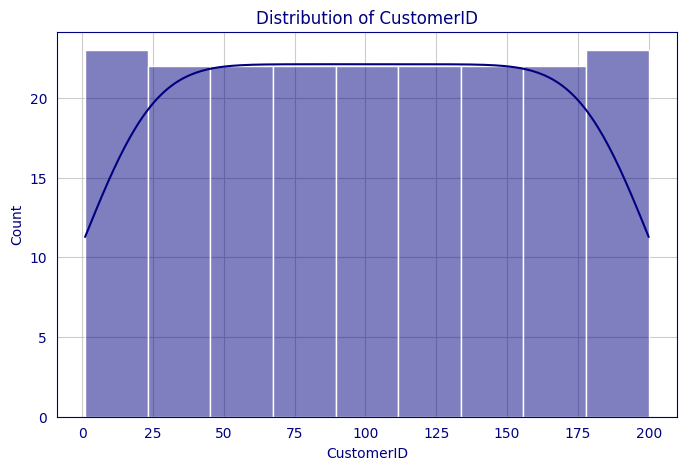

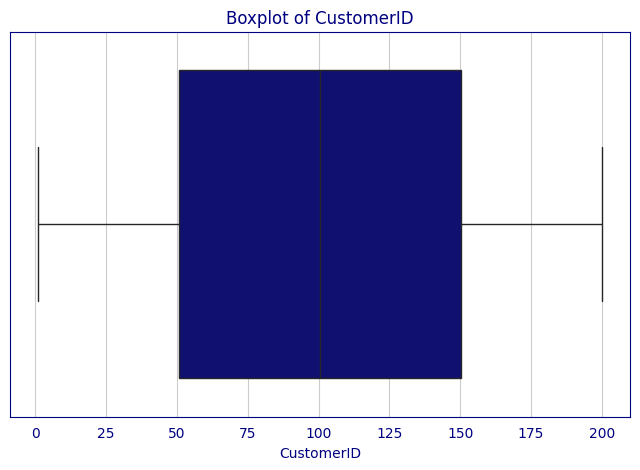

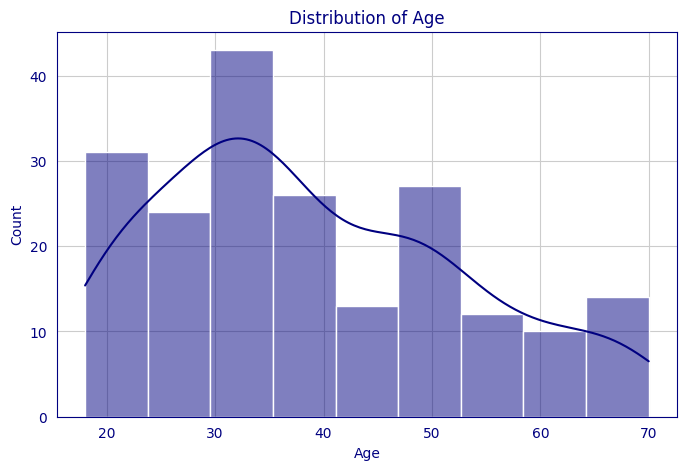

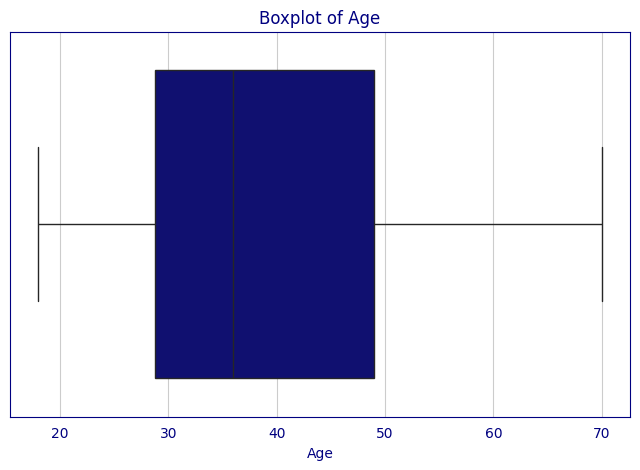

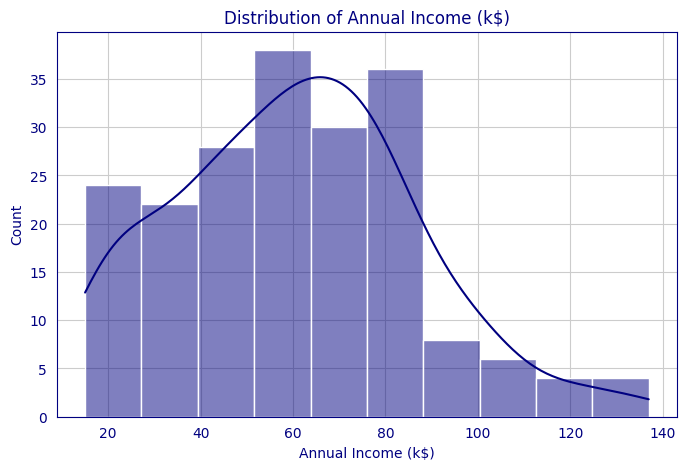

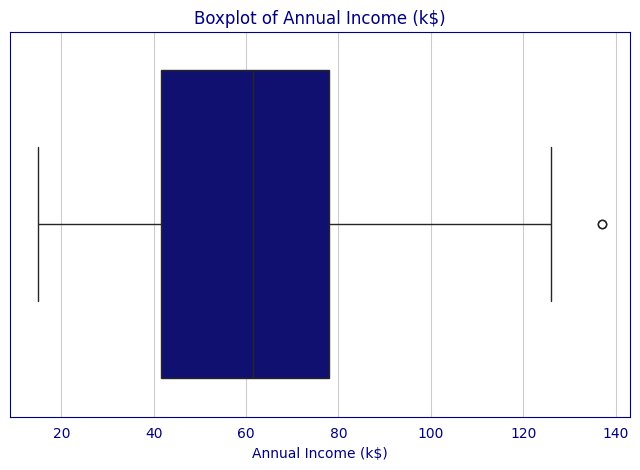

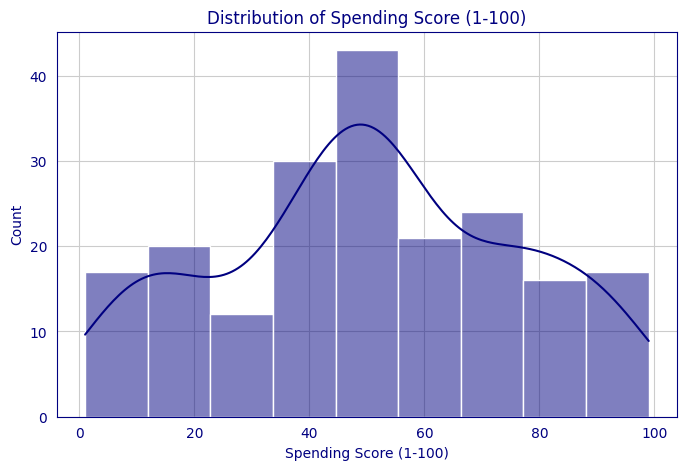

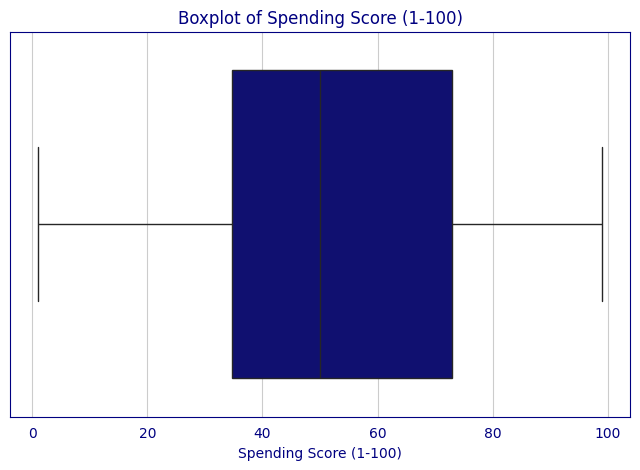

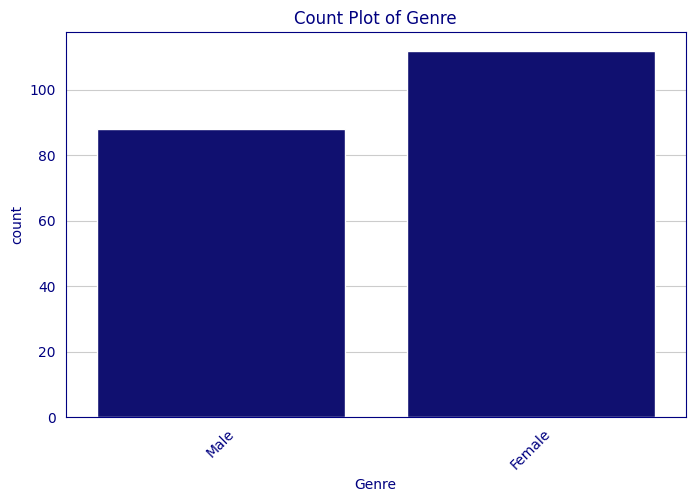


Skewness Before Correction:
CustomerID                0.000000
Age                       0.485569
Annual Income (k$)        0.291249
Spending Score (1-100)   -0.047220
dtype: float64

Skewness After Correction:
CustomerID                0.000000
Age                       0.485569
Annual Income (k$)        0.291249
Spending Score (1-100)   -0.047220
dtype: float64


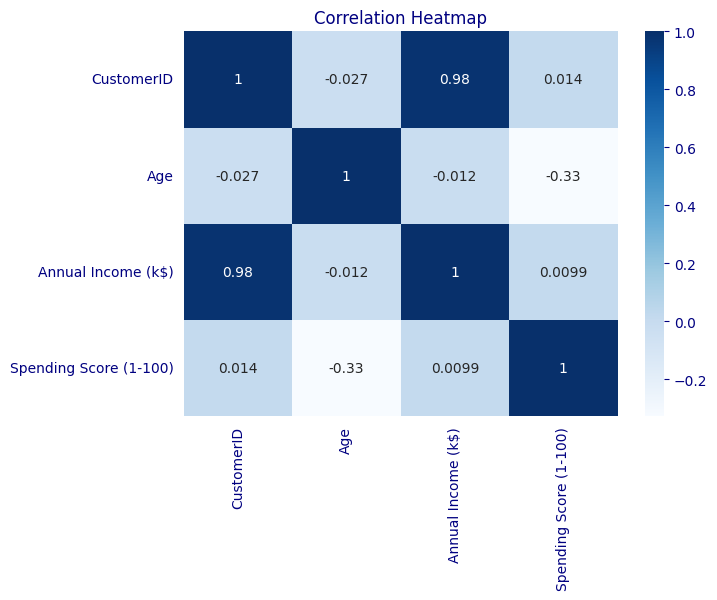

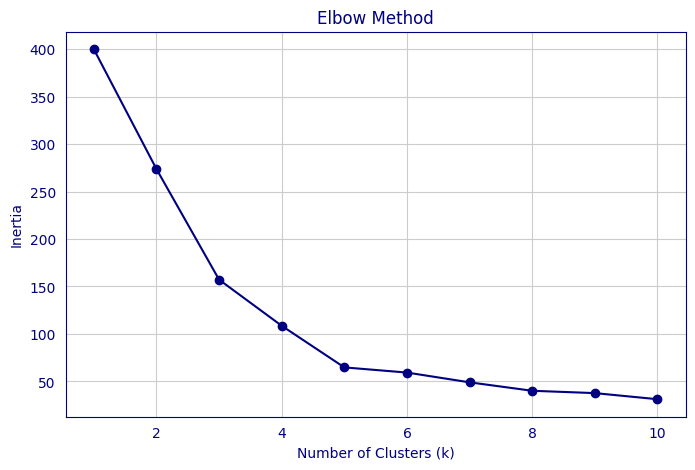


Silhouette Score: 0.5555014501078793


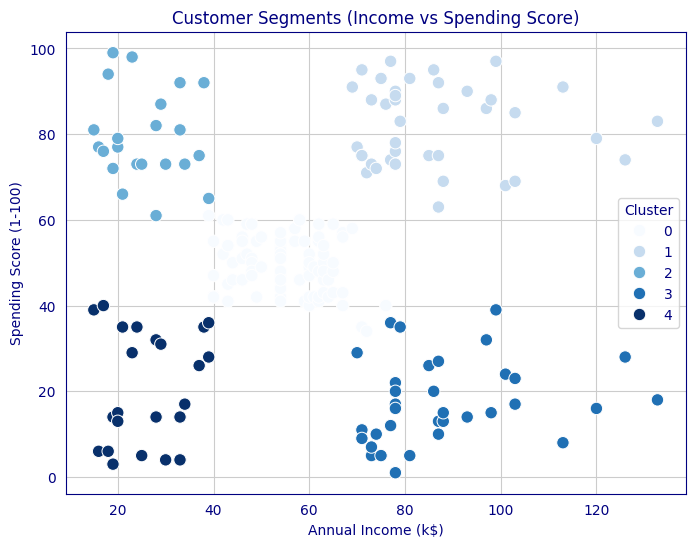


Cluster Summary:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.429487               82.128205
2                 25.727273               79.363636
3                 88.078571               17.114286
4                 26.304348               20.913043

FINAL SUMMARY:
Customer segmentation completed successfully.
Clusters formed based on Annual Income and Spending Score.
Silhouette score indicates cluster quality.
Dataset fully preprocessed and visualized.
Project 1 is complete and ready for submission.


In [ ]:
# =============================================================
# PROJECT: Customer Segmentation using K-Means
# AUTHOR: VM (Valarmathi) – Data Scientist Intern
# ORGANIZATION: ClingeBridge Solutions
# DATE: 2025-01-24
# VERSION: 6.0
#
# DESCRIPTION:
# This script performs:
# - File Upload from System
# - Univariate & Bivariate EDA
# - Missing Value Handling
# - Outlier Detection & Treatment (IQR)
# - Skewness Detection & Correction
# - Scaling (StandardScaler)
# - Correlation Heatmap
# - K-Means Clustering
# - Silhouette Score
# - Cluster Visualization
# - Cluster Interpretation
# =============================================================

# -------------------------------------------------------------
# Step 1: Upload Dataset from System
# -------------------------------------------------------------
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the uploaded file
df = pd.read_csv("Mall_Customers.csv")
print("Dataset Loaded Successfully")
df.head()

# -------------------------------------------------------------
# Step 2: Basic Information
# -------------------------------------------------------------
print("\nDataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe(include="all"))

# -------------------------------------------------------------
# Step 3: Missing Values – Detection & Handling
# -------------------------------------------------------------
print("\nMissing Values Before Handling:")
print(df.isnull().sum())

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numerical Imputation (Median)
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical Imputation (Mode)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Handling:")
print(df.isnull().sum())

# -------------------------------------------------------------
# Step 4: Navy Blue Theme for Visuals
# -------------------------------------------------------------
sns.set_style("whitegrid")
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'navy'
plt.rcParams['axes.labelcolor'] = 'navy'
plt.rcParams['xtick.color'] = 'navy'
plt.rcParams['ytick.color'] = 'navy'
plt.rcParams['text.color'] = 'navy'
plt.rcParams['figure.figsize'] = (8,5)

# -------------------------------------------------------------
# Step 5: Univariate Analysis
# -------------------------------------------------------------
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, color='navy')
    plt.title(f"Distribution of {col}", color='navy')
    plt.show()

    plt.figure()
    sns.boxplot(x=df[col], color='navy')
    plt.title(f"Boxplot of {col}", color='navy')
    plt.show()

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col], color='navy')
    plt.title(f"Count Plot of {col}", color='navy')
    plt.xticks(rotation=45)
    plt.show()

# -------------------------------------------------------------
# Step 6: Outlier Detection & Treatment (IQR Method)
# -------------------------------------------------------------
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper,
                np.where(df[col] < lower, lower, df[col]))

# -------------------------------------------------------------
# Step 7: Skewness Detection & Correction
# -------------------------------------------------------------
print("\nSkewness Before Correction:")
print(df[num_cols].skew())

for col in num_cols:
    if (df[col] > 0).all() and abs(df[col].skew()) > 0.75:
        df[col] = np.log(df[col] + 1)

print("\nSkewness After Correction:")
print(df[num_cols].skew())

# -------------------------------------------------------------
# Step 8: Correlation Heatmap
# -------------------------------------------------------------
plt.figure(figsize=(7,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap", color='navy')
plt.show()

# -------------------------------------------------------------
# Step 9: Select Features for Clustering
# -------------------------------------------------------------
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# -------------------------------------------------------------
# Step 10: Scaling
# -------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------------------------------------
# Step 11: Elbow Method
# -------------------------------------------------------------
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o', color='navy')
plt.title("Elbow Method", color='navy')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

# -------------------------------------------------------------
# Step 12: Apply K-Means (k = 5)
# -------------------------------------------------------------
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# -------------------------------------------------------------
# Step 13: Silhouette Score
# -------------------------------------------------------------
score = silhouette_score(X_scaled, df['Cluster'])
print("\nSilhouette Score:", score)

# -------------------------------------------------------------
# Step 14: Cluster Visualization
# -------------------------------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X['Annual Income (k$)'],
    y=X['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Blues',
    s=80
)
plt.title("Customer Segments (Income vs Spending Score)", color='navy')
plt.legend(title="Cluster")
plt.show()

# -------------------------------------------------------------
# Step 15: Cluster Interpretation
# -------------------------------------------------------------
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("\nCluster Summary:")
print(cluster_summary)

# -------------------------------------------------------------
# Step 16: Final Summary
# -------------------------------------------------------------
print("\nFINAL SUMMARY:")
print("Customer segmentation completed successfully.")
print("Clusters formed based on Annual Income and Spending Score.")
print("Silhouette score indicates cluster quality.")
print("Dataset fully preprocessed and visualized.")
print("Project 1 is complete and ready for submission.")

# -------------------------------------------------------------
# End of Script
# -------------------------------------------------------------


In [ ]:
# =============================================================
# PROJECT 2: Sentiment Analysis using TF-IDF + ML Models
# AUTHOR: VM (Valarmathi) – Data Scientist Intern
# ORGANIZATION: ClingeBridge Solutions
# DATE: 2025-01-24
# VERSION: 4.0
#
# Dataset Source: NLTK Movie Reviews (Built-in, No URL Needed)
# =============================================================

# -------------------------------------------------------------
# Step 1: Import Libraries
# -------------------------------------------------------------
import nltk
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import movie_reviews
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# -------------------------------------------------------------
# Step 2: Load NLTK Movie Reviews Dataset
# -------------------------------------------------------------
reviews = []
sentiments = []

for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        reviews.append(movie_reviews.raw(fileid))
        sentiments.append(category)

df = pd.DataFrame({"review": reviews, "sentiment": sentiments})
print("Dataset Loaded Successfully")
df.head()

# -------------------------------------------------------------
# Step 3: Text Cleaning
# -------------------------------------------------------------
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned'] = df['review'].apply(clean_text)

# -------------------------------------------------------------
# Step 4: TF-IDF Vectorization
# -------------------------------------------------------------
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned'])
y = df['sentiment']

# -------------------------------------------------------------
# Step 5: Train-Test Split
# -------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -------------------------------------------------------------
# Step 6: Train Models
# -------------------------------------------------------------
log_model = LogisticRegression(max_iter=300)
log_model.fit(X_train, y_train)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# -------------------------------------------------------------
# Step 7: Predictions
# -------------------------------------------------------------
log_pred = log_model.predict(X_test)
nb_pred = nb_model.predict(X_test)

# -------------------------------------------------------------
# Step 8: Evaluation Function
# -------------------------------------------------------------
def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} Evaluation ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, pos_label='pos'))
    print("Recall   :", recall_score(y_true, y_pred, pos_label='pos'))
    print("F1 Score :", f1_score(y_true, y_pred, pos_label='pos'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

evaluate_model("Logistic Regression", y_test, log_pred)
evaluate_model("Naive Bayes", y_test, nb_pred)

# -------------------------------------------------------------
# Step 9: Predict Sentiment for New Reviews
# -------------------------------------------------------------
def predict_sentiment(review):
    cleaned = clean_text(review)
    vector = tfidf.transform([cleaned])
    log_result = log_model.predict(vector)[0]
    nb_result = nb_model.predict(vector)[0]

    print("\nReview:", review)
    print("Logistic Regression Prediction:", log_result)
    print("Naive Bayes Prediction:", nb_result)

predict_sentiment("This movie was absolutely amazing!")
predict_sentiment("Worst movie ever, total waste of time.")

# -------------------------------------------------------------
# End of Script
# -------------------------------------------------------------


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset Loaded Successfully

=== Logistic Regression Evaluation ===
Accuracy : 0.81
Precision: 0.8032786885245902
Recall   : 0.8065843621399177
F1 Score : 0.8049281314168378

Classification Report:
               precision    recall  f1-score   support

         neg       0.82      0.81      0.81       257
         pos       0.80      0.81      0.80       243

    accuracy                           0.81       500
   macro avg       0.81      0.81      0.81       500
weighted avg       0.81      0.81      0.81       500


=== Naive Bayes Evaluation ===
Accuracy : 0.796
Precision: 0.8025751072961373
Recall   : 0.7695473251028807
F1 Score : 0.7857142857142857

Classification Report:
               precision    recall  f1-score   support

         neg       0.79      0.82      0.81       257
         pos       0.80      0.77      0.79       243

    accuracy                           0.80       500
   macro avg       0.80      0.80      0.80       500
weighted avg       0.80      0.80     

/tmp/ipython-input-260401077.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_symbol, start="2010-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed



Dataset Loaded Successfully
Price            Close
Ticker         BTC-USD
Date                  
2014-09-17  457.334015
2014-09-18  424.440002
2014-09-19  394.795990
2014-09-20  408.903992
2014-09-21  398.821014


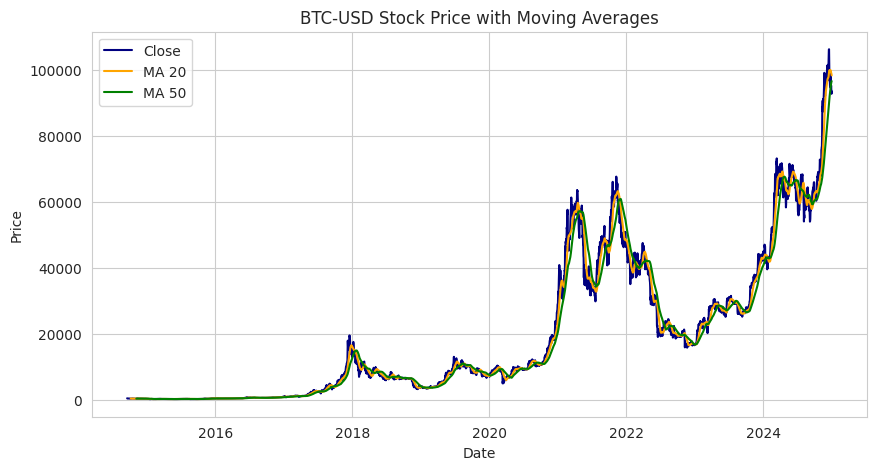


Train shape: (3729, 3)
Test shape : (30, 3)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                 3729
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -30736.518
Date:                Wed, 24 Dec 2025   AIC                          61485.035
Time:                        01:42:53   BIC                          61522.377
Sample:                    09-17-2014   HQIC                         61498.320
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0339      0.009     -3.887      0.000      -0.051      -0.017
ar.L2          0.0312      0.009      3.452      0.001       0.014       0.049
ar.L3          0.0012      0.0

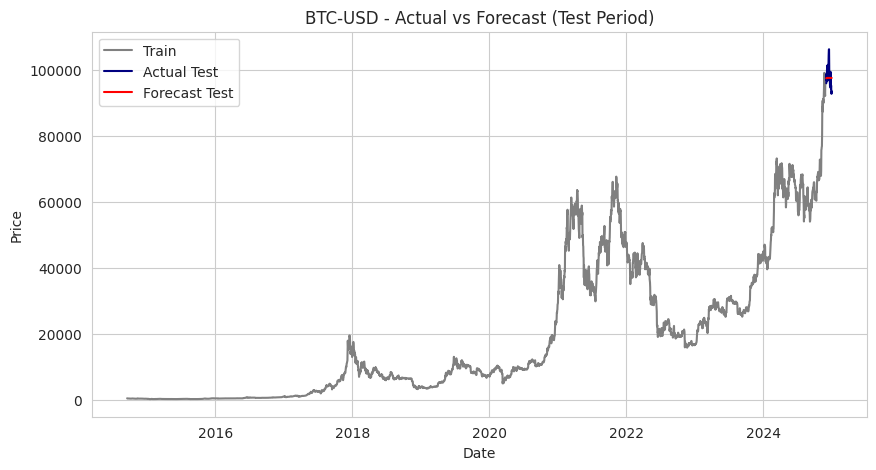

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


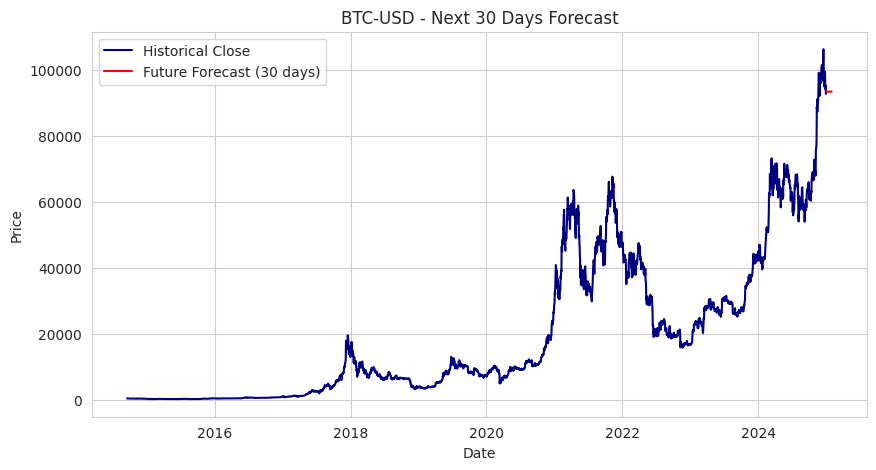


Next 30 Days Forecast:
2025-01-01    93381.674435
2025-01-02    93374.549200
2025-01-03    93295.518802
2025-01-04    93300.612863
2025-01-05    93318.848461
2025-01-06    93317.136473
2025-01-07    93314.652406
2025-01-08    93312.629035
2025-01-09    93313.414365
2025-01-10    93313.800730
2025-01-11    93313.680787
2025-01-12    93313.552206
2025-01-13    93313.523674
2025-01-14    93313.557270
2025-01-15    93313.562660
2025-01-16    93313.555612
2025-01-17    93313.551315
2025-01-18    93313.551656
2025-01-19    93313.552694
2025-01-20    93313.552593
2025-01-21    93313.552276
2025-01-22    93313.552174
2025-01-23    93313.552217
2025-01-24    93313.552240
2025-01-25    93313.552227
2025-01-26    93313.552215
2025-01-27    93313.552214
2025-01-28    93313.552216
2025-01-29    93313.552216
2025-01-30    93313.552215
Freq: D, dtype: float64


In [ ]:
# =============================================================
# PROJECT 3: Stock Price Forecasting using ARIMA
# AUTHOR: VM (Valarmathi) – Data Scientist Intern
# ORGANIZATION: ClingeBridge Solutions
# DATE: 2025-01-24
# VERSION: 2.0
#
# TASKS:
# - Auto-download stock data from Yahoo Finance
# - Plot stock trend + moving averages
# - Fit ARIMA model
# - Forecast next 30 days
# - Compare forecast with actual test data
# =============================================================

# -------------------------------------------------------------
# Step 1: Import Libraries
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# -------------------------------------------------------------
# Step 2: Enter Stock Symbol (Example: AAPL, TSLA, RELIANCE.NS)
# -------------------------------------------------------------
stock_symbol = "BTC-USD"   # <<< CHANGE THIS TO ANY STOCK YOU WANT

print(f"Downloading data for: {stock_symbol}")

df = yf.download(stock_symbol, start="2010-01-01", end="2025-01-01")

df = df[['Close']]
df.dropna(inplace=True)

print("\nDataset Loaded Successfully")
print(df.head())

# -------------------------------------------------------------
# Step 3: Plot Stock Trend + Moving Averages
# -------------------------------------------------------------
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

plt.figure()
plt.plot(df['Close'], label='Close', color='navy')
plt.plot(df['MA20'], label='MA 20', color='orange')
plt.plot(df['MA50'], label='MA 50', color='green')
plt.title(f"{stock_symbol} Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# -------------------------------------------------------------
# Step 4: Train-Test Split (Last 30 days as Test)
# -------------------------------------------------------------
test_size = 30
train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

print("\nTrain shape:", train.shape)
print("Test shape :", test.shape)

# -------------------------------------------------------------
# Step 5: Fit ARIMA Model
# -------------------------------------------------------------
p, d, q = 5, 1, 0  # basic ARIMA order

model = ARIMA(train['Close'], order=(p, d, q))
model_fit = model.fit()

print("\nARIMA Model Summary:")
print(model_fit.summary())

# -------------------------------------------------------------
# Step 6: Forecast for Test Period
# -------------------------------------------------------------
forecast_test = model_fit.forecast(steps=test_size)
forecast_test = pd.Series(forecast_test, index=test.index)

rmse = math.sqrt(mean_squared_error(test['Close'], forecast_test))
print(f"\nRMSE on Test Period: {rmse:.4f}")

plt.figure()
plt.plot(train['Close'], label='Train', color='grey')
plt.plot(test['Close'], label='Actual Test', color='navy')
plt.plot(forecast_test, label='Forecast Test', color='red')
plt.title(f"{stock_symbol} - Actual vs Forecast (Test Period)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# -------------------------------------------------------------
# Step 7: Refit on Full Data & Forecast Next 30 Days
# -------------------------------------------------------------
final_model = ARIMA(df['Close'], order=(p, d, q))
final_fit = final_model.fit()

future_steps = 30
future_forecast = final_fit.forecast(steps=future_steps)

last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=future_steps, freq='D')

future_series = pd.Series(future_forecast.values, index=future_dates)

plt.figure()
plt.plot(df['Close'], label='Historical Close', color='navy')
plt.plot(future_series, label='Future Forecast (30 days)', color='red')
plt.title(f"{stock_symbol} - Next 30 Days Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

print("\nNext 30 Days Forecast:")
print(future_series)

# -------------------------------------------------------------
# End of Script
# -------------------------------------------------------------


In [ ]:
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.6 MB/s eta 0:00:00


/tmp/ipython-input-3012660188.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_symbol, start="2010-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Dataset Loaded Successfully
Price            Close
Ticker         BTC-USD
Date                  
2014-09-17  457.334015
2014-09-18  424.440002
2014-09-19  394.795990
2014-09-20  408.903992
2014-09-21  398.821014


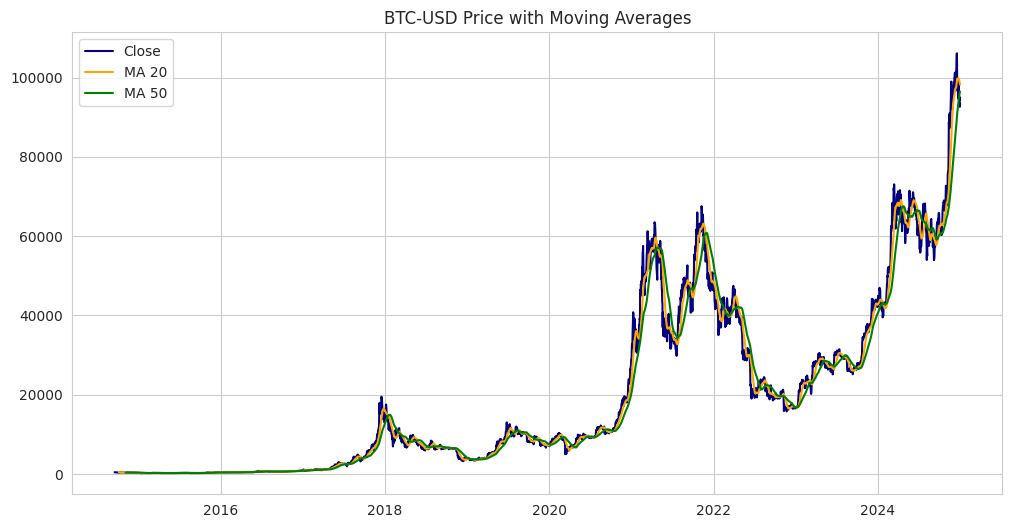

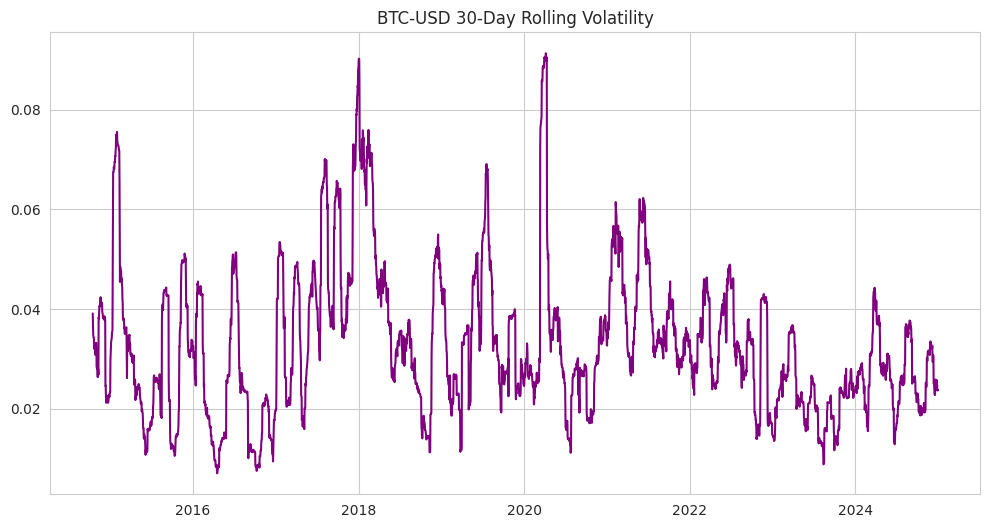


=== ADF Test ===
ADF Statistic: 0.037362006967710935
p-value: 0.9615149722629615
Non-Stationary

Running Auto-ARIMA...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=61487.198, Time=3.57 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=61487.992, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=61485.410, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=61485.691, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=61488.945, Time=0.07 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=61483.758, Time=0.36 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=61485.758, Time=0.48 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=61485.759, Time=0.42 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=61484.861, Time=1.08 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=61487.758, Time=0.66 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=61484.726, Time=0.18 sec

Best model:  ARIMA(2,1,0)(0,0,0)[0] intercept
Total fit time: 7.420 seconds

Best ARIMA Model Found

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                 3729
Model:                 ARIMA(2, 1, 0)   Log Likelihood              -30739.363
Date:                Wed, 24 Dec 2025   AIC                          61484.726
Time:                        01:56:35   BIC                          61503.397
Sample:                    09-17-2014   HQIC                         61491.368
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0331      0.009     -3.857      0.000      -0.050      -0.016
ar.L2          0.0321      0.009      3.567      0.000       0.014       0.050
sigma2      8.506e+05   7142.3

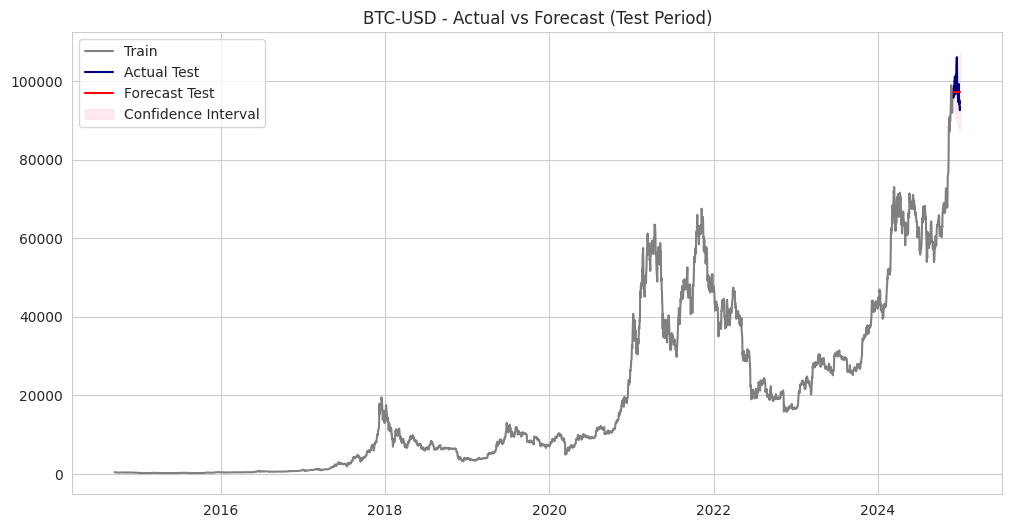


=== Actual vs Forecast (Last 30 Days) ===
                   Actual      Forecast
Date                                   
2024-12-02   95865.304688  97219.729975
2024-12-03   96002.164062  97248.410298
2024-12-04   98768.531250  97245.530251
2024-12-05   96593.570312  97246.547141
2024-12-06   99920.710938  97246.420911
2024-12-07   99923.335938  97246.457765
2024-12-08  101236.015625  97246.452488
2024-12-09   97432.718750  97246.453847
2024-12-10   96675.429688  97246.453632
2024-12-11  101173.031250  97246.453683
2024-12-12  100043.000000  97246.453675
2024-12-13  101459.257812  97246.453677
2024-12-14  101372.968750  97246.453676
2024-12-15  104298.695312  97246.453676
2024-12-16  106029.718750  97246.453676
2024-12-17  106140.601562  97246.453676
2024-12-18  100041.539062  97246.453676
2024-12-19   97490.953125  97246.453676
2024-12-20   97755.929688  97246.453676
2024-12-21   97224.726562  97246.453676
2024-12-22   95104.937500  97246.453676
2024-12-23   94686.242188  97246.4536

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


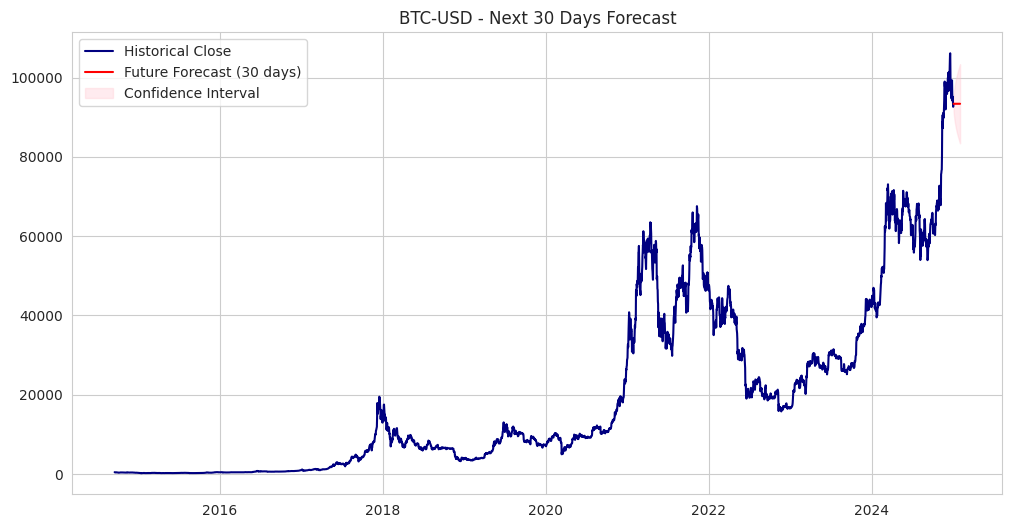


Next 30 Days Forecast:
2025-01-01    93385.160836
2025-01-02    93402.671894
2025-01-03    93401.194601
2025-01-04    93401.601088
2025-01-05    93401.557500
2025-01-06    93401.567243
2025-01-07    93401.566031
2025-01-08    93401.566270
2025-01-09    93401.566237
2025-01-10    93401.566243
2025-01-11    93401.566242
2025-01-12    93401.566243
2025-01-13    93401.566243
2025-01-14    93401.566243
2025-01-15    93401.566243
2025-01-16    93401.566243
2025-01-17    93401.566243
2025-01-18    93401.566243
2025-01-19    93401.566243
2025-01-20    93401.566243
2025-01-21    93401.566243
2025-01-22    93401.566243
2025-01-23    93401.566243
2025-01-24    93401.566243
2025-01-25    93401.566243
2025-01-26    93401.566243
2025-01-27    93401.566243
2025-01-28    93401.566243
2025-01-29    93401.566243
2025-01-30    93401.566243
Freq: D, dtype: float64

=== FINAL SUMMARY ===
Stock: BTC-USD
Best ARIMA Model: (2, 1, 0)
RMSE (Test): 3613.7206
MAPE (Test): 2.85%
Forecast for next 30 days generate

In [ ]:
# Install pmdarima (required for auto_arima)
!pip install pmdarima

# =============================================================
# PROJECT 3: Stock Price Forecasting using ARIMA & Auto-ARIMA
# AUTHOR: VM (Valarmathi) – Data Scientist Intern
# ORGANIZATION: ClingeBridge Solutions
# DATE: 2025-01-24
# VERSION: 3.2 (Final Updated)
# =============================================================

# -------------------------------------------------------------
# Step 1: Import Libraries
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from pmdarima import auto_arima
import math

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# -------------------------------------------------------------
# Step 2: Enter Stock Symbol
# -------------------------------------------------------------
stock_symbol = "BTC-USD"   # <<< CHANGE THIS TO ANY STOCK YOU WANT

print(f"Downloading data for: {stock_symbol}")

df = yf.download(stock_symbol, start="2010-01-01", end="2025-01-01")
df = df[['Close']]
df.dropna(inplace=True)

print("\nDataset Loaded Successfully")
print(df.head())

# -------------------------------------------------------------
# Step 3: Plot Trend + Moving Averages
# -------------------------------------------------------------
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()

plt.plot(df['Close'], label='Close', color='navy')
plt.plot(df['MA20'], label='MA 20', color='orange')
plt.plot(df['MA50'], label='MA 50', color='green')
plt.title(f"{stock_symbol} Price with Moving Averages")
plt.legend()
plt.show()

# -------------------------------------------------------------
# Step 4: Volatility Analysis
# -------------------------------------------------------------
df['Returns'] = df['Close'].pct_change()
df['Volatility'] = df['Returns'].rolling(30).std()

plt.plot(df['Volatility'], color='purple')
plt.title(f"{stock_symbol} 30-Day Rolling Volatility")
plt.show()

# -------------------------------------------------------------
# Step 5: Stationarity Check (ADF Test)
# -------------------------------------------------------------
adf_result = adfuller(df['Close'].dropna())

print("\n=== ADF Test ===")
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print("Stationary" if adf_result[1] < 0.05 else "Non-Stationary")

# -------------------------------------------------------------
# Step 6: Train-Test Split (Last 30 days as Test)
# -------------------------------------------------------------
test_size = 30
train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

# -------------------------------------------------------------
# Step 7: Auto-ARIMA (Best Model Selection)
# -------------------------------------------------------------
print("\nRunning Auto-ARIMA...")

auto_model = auto_arima(
    train['Close'],
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print("\nBest ARIMA Model Found:", auto_model.order)

# -------------------------------------------------------------
# Step 8: Fit Final ARIMA Model
# -------------------------------------------------------------
p, d, q = auto_model.order

model = ARIMA(train['Close'], order=(p, d, q))
model_fit = model.fit()

print("\nARIMA Model Summary:")
print(model_fit.summary())

# -------------------------------------------------------------
# Step 9: Forecast Test Period (FIXED)
# -------------------------------------------------------------
forecast_test = model_fit.get_forecast(steps=test_size)

# FINAL FIX: Convert forecast to 1D array
forecast_values = forecast_test.predicted_mean.to_numpy().reshape(-1)

conf_int = forecast_test.conf_int()

rmse = math.sqrt(mean_squared_error(test['Close'], forecast_values))
mape = mean_absolute_percentage_error(test['Close'], forecast_values) * 100

print(f"\nRMSE on Test Period: {rmse:.4f}")
print(f"MAPE on Test Period: {mape:.2f}%")

# Plot
plt.plot(train['Close'], label='Train', color='grey')
plt.plot(test['Close'], label='Actual Test', color='navy')
plt.plot(test.index, forecast_values, label='Forecast Test', color='red')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='Confidence Interval')
plt.title(f"{stock_symbol} - Actual vs Forecast (Test Period)")
plt.legend()
plt.show()

# -------------------------------------------------------------
# Step 10: Actual vs Forecast Table (FINAL FIX)
# -------------------------------------------------------------

# Flatten both arrays to 1D
actual_values = test['Close'].values.reshape(-1)
forecast_values = forecast_values.reshape(-1)

comparison = pd.DataFrame({
    "Actual": actual_values,
    "Forecast": forecast_values
}, index=test.index)

print("\n=== Actual vs Forecast (Last 30 Days) ===")
print(comparison)

# -------------------------------------------------------------
# Step 11: Forecast Next 30 Days
# -------------------------------------------------------------
final_model = ARIMA(df['Close'], order=(p, d, q))
final_fit = final_model.fit()

future_steps = 30
future_forecast = final_fit.get_forecast(steps=future_steps)
future_values = future_forecast.predicted_mean
future_conf = future_forecast.conf_int()

last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=future_steps, freq='D')

future_series = pd.Series(future_values.values, index=future_dates)

plt.plot(df['Close'], label='Historical Close', color='navy')
plt.plot(future_series, label='Future Forecast (30 days)', color='red')
plt.fill_between(future_dates, future_conf.iloc[:, 0], future_conf.iloc[:, 1],
                 color='pink', alpha=0.3, label='Confidence Interval')
plt.title(f"{stock_symbol} - Next 30 Days Forecast")
plt.legend()
plt.show()

print("\nNext 30 Days Forecast:")
print(future_series)

# -------------------------------------------------------------
# Step 12: Final Summary
# -------------------------------------------------------------
print("\n=== FINAL SUMMARY ===")
print(f"Stock: {stock_symbol}")
print(f"Best ARIMA Model: {auto_model.order}")
print(f"RMSE (Test): {rmse:.4f}")
print(f"MAPE (Test): {mape:.2f}%")
print("Forecast for next 30 days generated successfully.")
print("Project 3 completed professionally.")


Saving train.csv to train.csv
Dataset Loaded Successfully


/tmp/ipython-input-1152074469.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-1152074469.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr


=== Logistic Regression ===
Accuracy : 0.7847533632286996
Precision: 0.7303370786516854
Recall   : 0.7303370786516854
ROC-AUC  : 0.8713734697300017

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82       134
           1       0.73      0.73      0.73        89

    accuracy                           0.78       223
   macro avg       0.78      0.78      0.78       223
weighted avg       0.78      0.78      0.78       223


=== Decision Tree ===
Accuracy : 0.8026905829596412
Precision: 0.8082191780821918
Recall   : 0.6629213483146067
ROC-AUC  : 0.8262200234781151

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.85       134
           1       0.81      0.66      0.73        89

    accuracy                           0.80       223
   macro avg       0.80      0.78      0.79       223
weighted avg       0.80      0.80      0.80       223


===

/tmp/ipython-input-1152074469.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


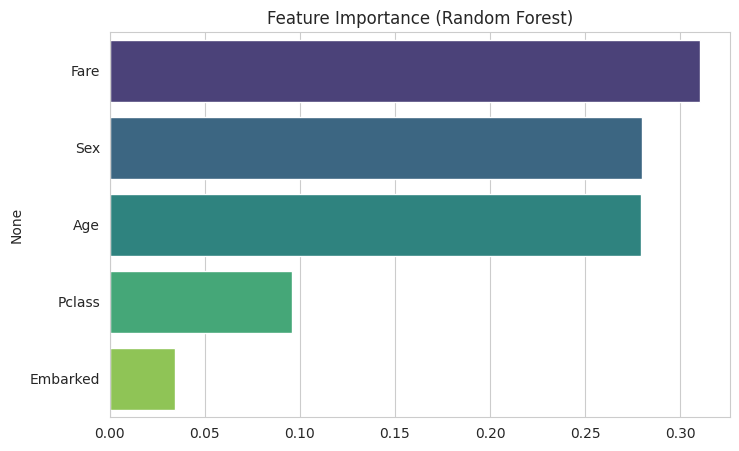


=== Feature Importance ===
Fare        0.310638
Sex         0.279774
Age         0.279433
Pclass      0.095747
Embarked    0.034407
dtype: float64


In [ ]:
# =============================================================
# PROJECT 4: Titanic Survival Prediction (Classification)
# AUTHOR: VM (Valarmathi) – Data Scientist Intern
# ORGANIZATION: ClingeBridge Solutions
# DATE: 2025-01-24
# VERSION: 1.0
# =============================================================

# -------------------------------------------------------------
# Step 1: Import Libraries
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")

# -------------------------------------------------------------
# Step 2: Load Dataset
# -------------------------------------------------------------
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
print("Dataset Loaded Successfully")
df.head()

# -------------------------------------------------------------
# Step 3: Clean Missing Data
# -------------------------------------------------------------
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# -------------------------------------------------------------
# Step 4: Encode Categorical Variables
# -------------------------------------------------------------
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])        # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked'])
df['Pclass'] = df['Pclass'].astype(int)

# -------------------------------------------------------------
# Step 5: Select Features
# -------------------------------------------------------------
features = ['Sex', 'Pclass', 'Age', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

# -------------------------------------------------------------
# Step 6: Train-Test Split
# -------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -------------------------------------------------------------
# Step 7: Train Models
# -------------------------------------------------------------
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)

tree_model = DecisionTreeClassifier(max_depth=5)
tree_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# -------------------------------------------------------------
# Step 8: Evaluation Function
# -------------------------------------------------------------
def evaluate_model(name, model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n=== {name} ===")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------------------------------------
# Step 9: Evaluate All Models
# -------------------------------------------------------------
evaluate_model("Logistic Regression", log_model)
evaluate_model("Decision Tree", tree_model)
evaluate_model("Random Forest", rf_model)

# -------------------------------------------------------------
# Step 10: Feature Importance (Random Forest)
# -------------------------------------------------------------
importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values(ascending=False, inplace=True)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()

print("\n=== Feature Importance ===")
print(importances)


<table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; width:100%; text-align:left;">
  <thead>
    <tr style="background-color:#f2f2f2;">
      <th>Project No.</th>
      <th>Title</th>
      <th>Main Technique</th>
      <th>Key Tasks</th>
      <th>What Makes It Special</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Project 1</td>
      <td>Customer Segmentation</td>
      <td>K-Means Clustering</td>
      <td>
        - Cleaned customer data<br>
        - Applied K-Means to group customers<br>
        - Visualized clusters for insights
      </td>
      <td>
        Shows your ability to understand customer behavior, work with unsupervised learning, and generate business insights from data.
      </td>
    </tr>
    <tr>
      <td>Project 2</td>
      <td>Sentiment Analysis</td>
      <td>NLP + TF-IDF + Classification</td>
      <td>
        - Processed text data from movie reviews<br>
        - Converted text to numerical features using TF-IDF<br>
        - Trained Logistic Regression & Naive Bayes
      </td>
      <td>
        Demonstrates your NLP skills and ability to handle unstructured text, turning language into measurable sentiment for real applications.
      </td>
    </tr>
    <tr>
      <td>Project 3</td>
      <td>Stock Price Forecasting</td>
      <td>ARIMA + Auto-ARIMA</td>
      <td>
        - Downloaded real BTC-USD data from Yahoo Finance<br>
        - Performed ADF test, moving averages, volatility analysis<br>
        - Built ARIMA model and forecasted next 30 days
      </td>
      <td>
        Proves you can work with time series, evaluate models using RMSE/MAPE, and generate practical future forecasts from real financial data.
      </td>
    </tr>
    <tr>
      <td>Project 4</td>
      <td>Titanic Survival Prediction</td>
      <td>Supervised Classification</td>
      <td>
        - Cleaned missing data (Age, Embarked)<br>
        - Encoded categorical variables (Sex, Pclass, Embarked)<br>
        - Trained Logistic Regression, Decision Tree, Random Forest
      </td>
      <td>
        Highlights your understanding of end-to-end ML: preprocessing, model comparison, evaluation with Accuracy/Precision/Recall/ROC-AUC, and feature importance.
      </td>
    </tr>
  </tbody>
</table>



**Thank YOU ALL**